# Border Crossing Entry Data — Full Analysis
## Data Mining Project

**Dataset:** U.S. Border Crossing Entry Data  
**Source:** Bureau of Transportation Statistics (BTS)  

### Project Overview
This notebook provides a complete end-to-end analysis of U.S. border crossing data including:
1. Data Loading and Overview
2. Exploratory Data Analysis
3. Data Preprocessing and Cleaning
4. Data Transformation
5. Clustering Analysis
6. Findings and Conclusions

In [1]:
# ── Imports ────────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Suppress KMeans memory warning on Windows
os.environ["OMP_NUM_THREADS"] = "1"

## Section 1 — Data Loading and Overview

The dataset is loaded directly from the BTS public API in CSV format.
The API returns border crossing records including port name, state, 
border, date, measure type, and crossing volume.

In [2]:
# Load cleaned data
df = pd.read_csv("data/cleaned/cleaned_border_crossing.csv")
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
df.head()

(49993, 10)


,port_name,state,port_code,border,date,measure,value,latitude,longitude,point
0,Richford,Vermont,203,US-Canada Border,2026-01-01,Personal Vehicles,4050,45.011740,-72.588559,POINT (-72.588559 45.01174)
1,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Trucks,208,31.334084,-109.948413,POINT (-109.948413 31.334084)
2,Naco,Arizona,2603,US-Mexico Border,2026-01-01,Truck Containers Empty,103,31.334084,-109.948413,POINT (-109.948413 31.334084)
3,Sumas,Washington,3009,US-Canada Border,2026-01-01,Rail Containers Empty,338,49.002388,-122.264805,POINT (-122.264805 49.002388)
4,Vanceboro,Maine,105,US-Canada Border,2026-01-01,Rail Containers Loaded,5908,45.568761,-67.428541,POINT (-67.428541 45.568761)


In [3]:
# ── Dataset Overview ───────────────────────────────────────────
# Check column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49993 entries, 0 to 49992
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   port_name  49993 non-null  object        
 1   state      49993 non-null  object        
 2   port_code  49993 non-null  int64         
 3   border     49993 non-null  object        
 4   date       49993 non-null  datetime64[ns]
 5   measure    49993 non-null  object        
 6   value      49993 non-null  int64         
 7   latitude   49993 non-null  float64       
 8   longitude  49993 non-null  float64       
 9   point      49993 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(5)
memory usage: 3.8+ MB


In [4]:
# ── Basic Statistics ───────────────────────────────────────────
df.describe()

,port_code,date,value,latitude,longitude
count,49993.000000,49993,4.999300e+04,49993.000000,49993.000000
mean,2380.044286,2023-03-25 04:41:12.826195712,3.466513e+04,43.241964,-98.549539
min,103.000000,2020-05-01 00:00:00,0.000000e+00,25.951550,-141.001444
25%,2301.000000,2021-11-01 00:00:00,1.020000e+02,32.673389,-112.817077
50%,3004.000000,2023-04-01 00:00:00,8.110000e+02,46.508611,-100.927612
75%,3323.000000,2024-09-01 00:00:00,8.760000e+03,48.999538,-82.423611
max,3814.000000,2026-01-01 00:00:00,2.302112e+06,62.614961,-66.980076
std,1222.907690,NaN,1.330184e+05,8.311686,18.319410


## Section 2 — Exploratory Data Analysis

Before cleaning or modeling, we explore the data visually to understand:
- Trends over time
- Volume differences between borders
- Most common crossing types
- Busiest ports
- Seasonal patterns

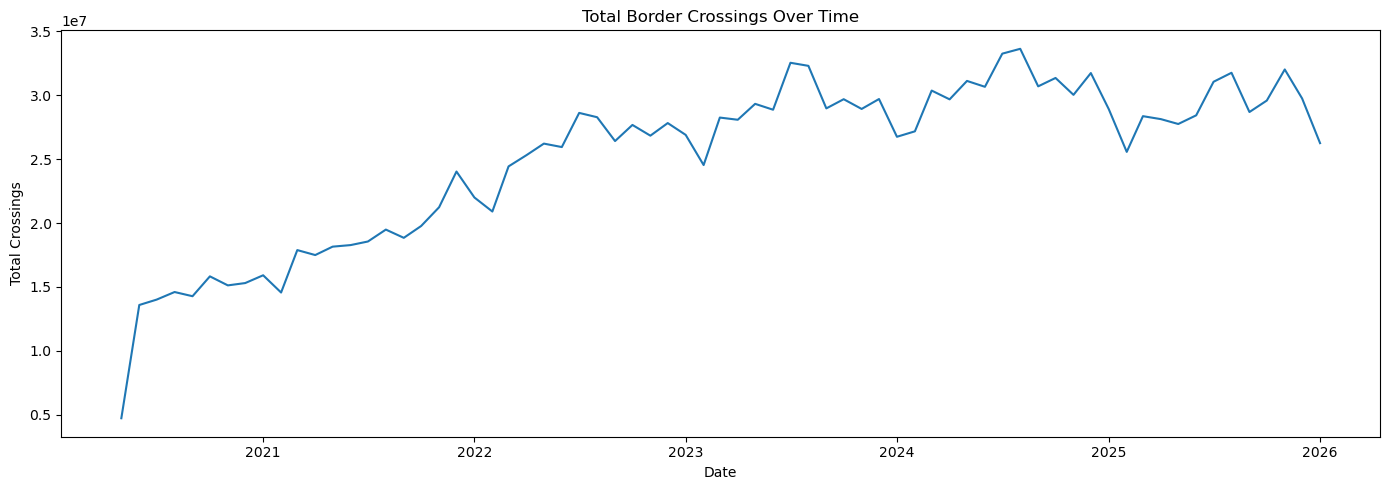


FINDING: Crossings dropped sharply in early 2020 due to COVID-19 border
restrictions. Recovery was gradual through 2021-2022, stabilizing around
28-33 million monthly crossings from 2023 onwards. A seasonal zigzag
pattern is visible throughout, suggesting monthly variation.



In [5]:
# ── EDA 1: Crossings Over Time ─────────────────────────────────
# Aggregate total crossings by date to see overall trend
df_time = df.groupby("date")["value"].sum().reset_index()
df_time["date"] = pd.to_datetime(df_time["date"])
df_time = df_time.sort_values("date")

plt.figure(figsize=(14, 5))
plt.plot(df_time["date"], df_time["value"])
plt.title("Total Border Crossings Over Time")
plt.xlabel("Date")
plt.ylabel("Total Crossings")
plt.tight_layout()
plt.show()

# Interpretation
print("""
FINDING: Crossings dropped sharply in early 2020 due to COVID-19 border
restrictions. Recovery was gradual through 2021-2022, stabilizing around
28-33 million monthly crossings from 2023 onwards. A seasonal zigzag
pattern is visible throughout, suggesting monthly variation.
""")

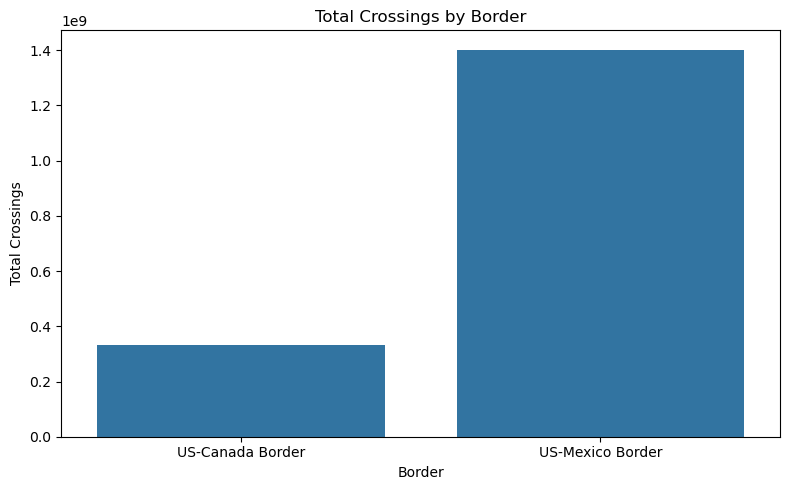


FINDING: The US-Mexico border sees approximately 4x more crossings than
the US-Canada border despite having fewer ports in the dataset. This
suggests US-Mexico ports handle far higher volumes per location.



In [6]:
# ── EDA 2: US-Canada vs US-Mexico ─────────────────────────────
# Compare total crossing volumes between the two borders
df_border = df.groupby("border")["value"].sum().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=df_border, x="border", y="value")
plt.title("Total Crossings by Border")
plt.xlabel("Border")
plt.ylabel("Total Crossings")
plt.tight_layout()
plt.show()

print("""
FINDING: The US-Mexico border sees approximately 4x more crossings than
the US-Canada border despite having fewer ports in the dataset. This
suggests US-Mexico ports handle far higher volumes per location.
""")


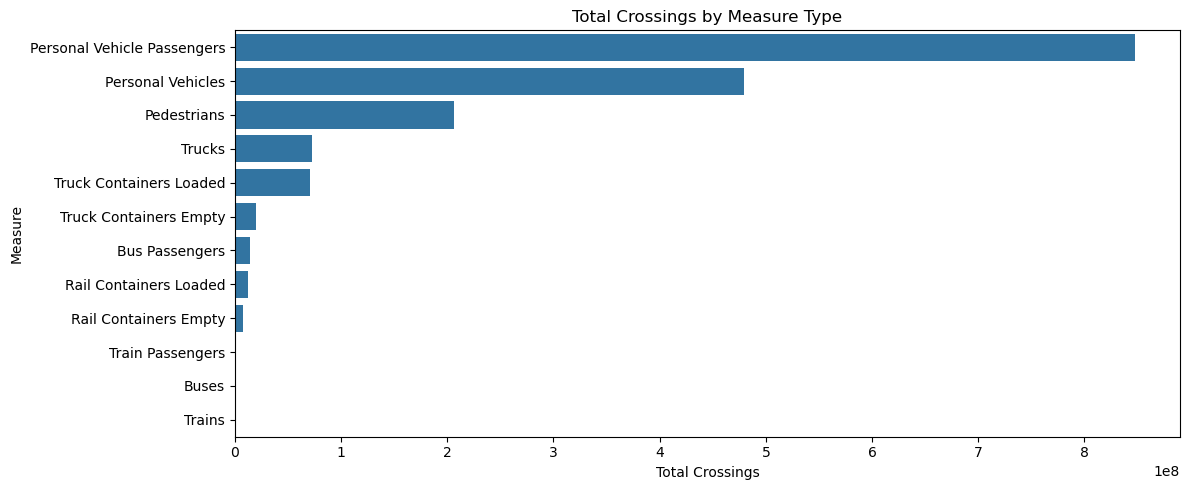


FINDING: Personal Vehicle Passengers and Personal Vehicles dominate
crossings by a large margin. Commercial traffic (trucks, rail, buses)
represents a small fraction. This confirms border crossings are driven
primarily by personal travel, not commerce.



In [7]:
# ── EDA 3: Crossings by Measure Type ──────────────────────────
# Understand what kinds of crossings dominate the data
df_measure = df.groupby("measure")["value"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_measure, x="value", y="measure")
plt.title("Total Crossings by Measure Type")
plt.xlabel("Total Crossings")
plt.ylabel("Measure")
plt.tight_layout()
plt.show()

print("""
FINDING: Personal Vehicle Passengers and Personal Vehicles dominate
crossings by a large margin. Commercial traffic (trucks, rail, buses)
represents a small fraction. This confirms border crossings are driven
primarily by personal travel, not commerce.
""")

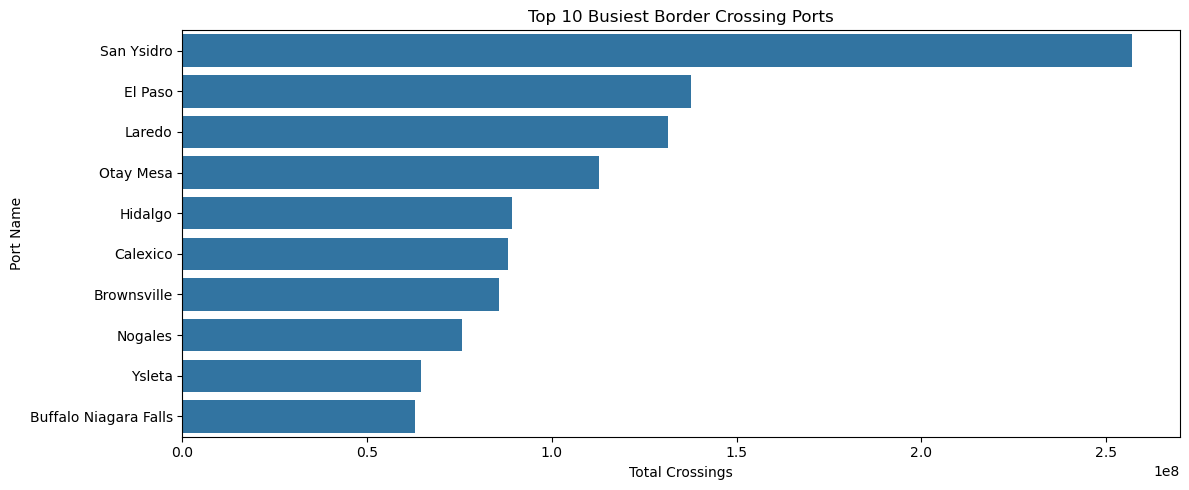


FINDING: San Ysidro (San Diego/Tijuana) is the busiest port by a massive
margin — nearly 2x the second busiest port. 9 of the top 10 ports are
US-Mexico, with Buffalo Niagara Falls being the only US-Canada port.
Texas alone accounts for 5 of the top 10 ports.



In [8]:
# ── EDA 4: Top 10 Busiest Ports ───────────────────────────────
# Identify which specific ports handle the most traffic
df_ports = df.groupby("port_name")["value"].sum().sort_values(
    ascending=False).head(10).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=df_ports, x="value", y="port_name")
plt.title("Top 10 Busiest Border Crossing Ports")
plt.xlabel("Total Crossings")
plt.ylabel("Port Name")
plt.tight_layout()
plt.show()

print("""
FINDING: San Ysidro (San Diego/Tijuana) is the busiest port by a massive
margin — nearly 2x the second busiest port. 9 of the top 10 ports are
US-Mexico, with Buffalo Niagara Falls being the only US-Canada port.
Texas alone accounts for 5 of the top 10 ports.
""")

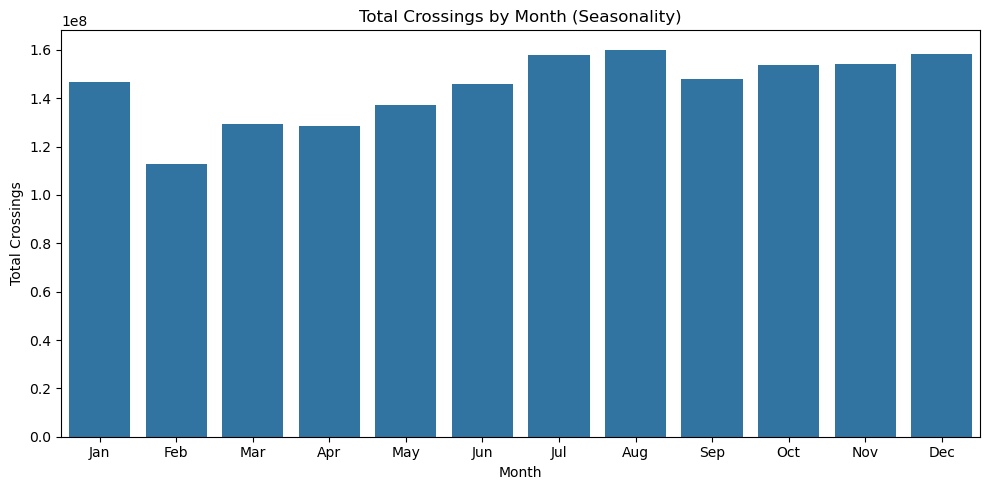


FINDING: July and August peak due to summer vacation travel. February
is the slowest month — shortest month combined with cold weather and
post-holiday period. December spikes due to holiday family travel.
The seasonal range is about 40% difference between highest and lowest months.



In [9]:
# ── EDA 5: Seasonality by Month ───────────────────────────────
# Check if certain months consistently see more crossings
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.month
df_month = df.groupby("month")["value"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=df_month, x="month", y="value")
plt.title("Total Crossings by Month (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Total Crossings")
plt.xticks(ticks=range(12), labels=["Jan","Feb","Mar","Apr","May",
                                     "Jun","Jul","Aug","Sep","Oct","Nov","Dec"])
plt.tight_layout()
plt.show()

print("""
FINDING: July and August peak due to summer vacation travel. February
is the slowest month — shortest month combined with cold weather and
post-holiday period. December spikes due to holiday family travel.
The seasonal range is about 40% difference between highest and lowest months.
""")

## Section 3 — Preprocessing and Cleaning

Based on our EDA we identified and resolved the following data quality issues:
- 7 rows with missing location data (latitude, longitude, point)
- 5 rows with missing state values
- Date column stored as string instead of datetime
- Text columns with potential whitespace or casing inconsistencies

In [10]:
# ── Check Missing Values ───────────────────────────────────────
print("Missing values before cleaning:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values before cleaning:
port_name    0
state        0
port_code    0
border       0
date         0
measure      0
value        0
latitude     0
longitude    0
point        0
month        0
dtype: int64

Duplicate rows: 0


In [11]:
# ── Clean the Data ─────────────────────────────────────────────

# 1. Convert date from string to datetime for time series analysis
df["date"] = pd.to_datetime(df["date"])

# 2. Drop rows missing location data (latitude, longitude, point)
# Decision: These 7 rows cannot be used for geographic analysis
# and represent incomplete records with no way to impute location
df.dropna(subset=["latitude", "longitude", "point"], inplace=True)

# 3. Standardize text columns
# Removes leading/trailing whitespace and ensures consistent casing
df["port_name"] = df["port_name"].str.strip().str.title()
df["state"]     = df["state"].str.strip().str.title()
df["border"]    = df["border"].str.strip()
df["measure"]   = df["measure"].str.strip()

# 4. Verify zero values — kept as legitimate data
# 4 rows have value=0, representing ports with no crossings
# on a given date (e.g., closed ports). These are valid data points.
zero_count = df[df["value"] == 0].shape[0]
print(f"Zero value rows kept as legitimate data: {zero_count}")

# ── Verify Cleaning Results ────────────────────────────────────
print(f"\nShape after cleaning: {df.shape}")
print(f"\nMissing values after cleaning:")
print(df.isnull().sum())
print(f"\nDate column type: {df['date'].dtype}")

Zero value rows kept as legitimate data: 4

Shape after cleaning: (49993, 11)

Missing values after cleaning:
port_name    0
state        0
port_code    0
border       0
date         0
measure      0
value        0
latitude     0
longitude    0
point        0
month        0
dtype: int64

Date column type: datetime64[ns]


## Section 4 — Data Transformation for Clustering

To apply K-Means clustering we need to transform the data from individual
crossing records into port-level features. Each port becomes one row
summarized by its total crossings, average crossings, and border type.
Features are then scaled using StandardScaler so no single feature
dominates due to differences in magnitude.

In [12]:
# ── Build Port Level Features ──────────────────────────────────

# Aggregate individual records into one row per port
port_total   = df.groupby("port_name")["value"].sum().rename("total_crossings")
port_avg     = df.groupby("port_name")["value"].mean().rename("avg_crossings")
port_measure = df.groupby("port_name")["measure"].agg(
    lambda x: x.value_counts().index[0]).rename("top_measure")
port_border  = df.groupby("port_name")["border"].first().rename("border")
port_state   = df.groupby("port_name")["state"].first().rename("state")

# Combine into single dataframe
port_df = pd.concat([port_total, port_avg, port_border,
                     port_state, port_measure], axis=1).reset_index()

print(f"Ports to cluster: {port_df.shape[0]}")
port_df.head(10)

Ports to cluster: 111


,port_name,total_crossings,avg_crossings,border,state,top_measure
0,Alcan,655149,1742.417553,US-Canada Border,Alaska,Personal Vehicle Passengers
1,Alexandria Bay,8853146,20352.059770,US-Canada Border,New York,Trucks
2,Algonac,376783,4095.467391,US-Canada Border,Michigan,Personal Vehicles
3,Ambrose,11299,66.857988,US-Canada Border,North Dakota,Personal Vehicles
4,Andrade,11102734,54159.678049,US-Mexico Border,California,Personal Vehicle Passengers
5,Antler,84807,272.691318,US-Canada Border,North Dakota,Trucks
6,Bar Harbor,108803,2266.729167,US-Canada Border,Maine,Personal Vehicles
7,Baudette,1397154,3175.350000,US-Canada Border,Minnesota,Trucks
8,Beecher Falls,690855,1968.247863,US-Canada Border,Vermont,Personal Vehicle Passengers
9,Blaine,40352994,56516.798319,US-Canada Border,Washington,Personal Vehicle Passengers


In [15]:
# ── Scale Features for Clustering ─────────────────────────────
# Encode border as binary numeric feature
# US-Mexico = 1, US-Canada = 0
port_df["border_encoded"] = (port_df["border"] == "US-Mexico Border").astype(int)

# Select features
features = port_df[["total_crossings", "avg_crossings", "border_encoded"]]

# StandardScaler transforms features to mean=0, std=1
# This prevents high-volume ports from dominating purely due to scale
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

print("Features scaled and ready for clustering!")
print(f"Feature matrix shape: {features_scaled.shape}")

Features scaled and ready for clustering!
Feature matrix shape: (111, 3)


## Section 5 — Clustering Analysis

We use K-Means clustering to group ports by behavioral similarity.
The elbow method is used to determine the optimal number of clusters
by finding where adding more clusters yields diminishing returns.

c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

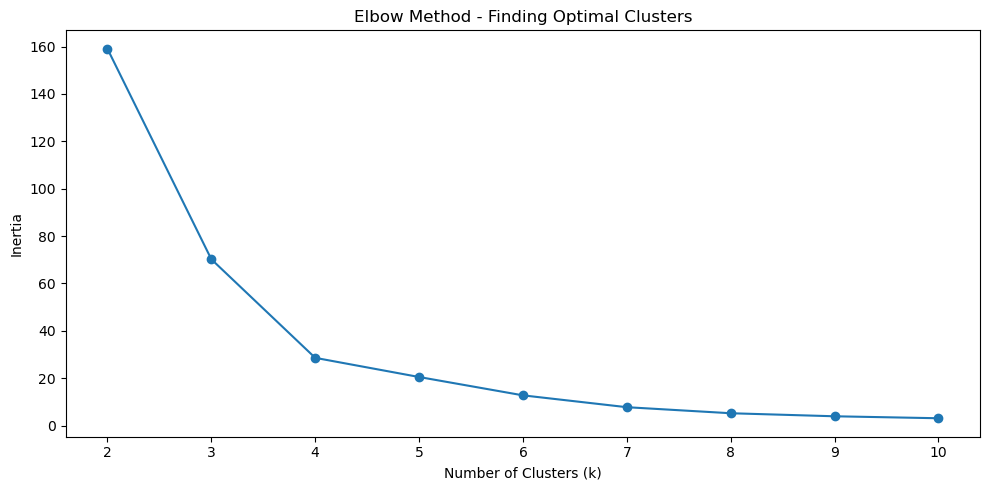

The elbow occurs at k=4 where the rate of decrease significantly slows.


In [16]:
# ── Elbow Method ───────────────────────────────────────────────
# Test k=2 through k=10 and measure inertia for each
# The optimal k is where the curve bends (the elbow)
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(k_range, inertia, marker="o")
plt.title("Elbow Method - Finding Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("The elbow occurs at k=4 where the rate of decrease significantly slows.")

In [17]:
# ── Apply KMeans with k=4 ──────────────────────────────────────
# k=4 chosen based on elbow method above
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
port_df["cluster"] = kmeans.fit_predict(features_scaled)

# Cluster summary
print("── Ports per Cluster ──")
print(port_df["cluster"].value_counts())

print("\n── Average Crossings per Cluster ──")
print(port_df.groupby("cluster")[["total_crossings",
      "avg_crossings"]].mean().round(0))

── Ports per Cluster ──
cluster
0    83
2    18
1     9
3     1
Name: count, dtype: int64

── Average Crossings per Cluster ──
         total_crossings  avg_crossings
cluster                                
0              3985973.0         6215.0
1             93974699.0       178904.0
2             16628016.0        41663.0
3            257101461.0       765183.0


c:\Users\write\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


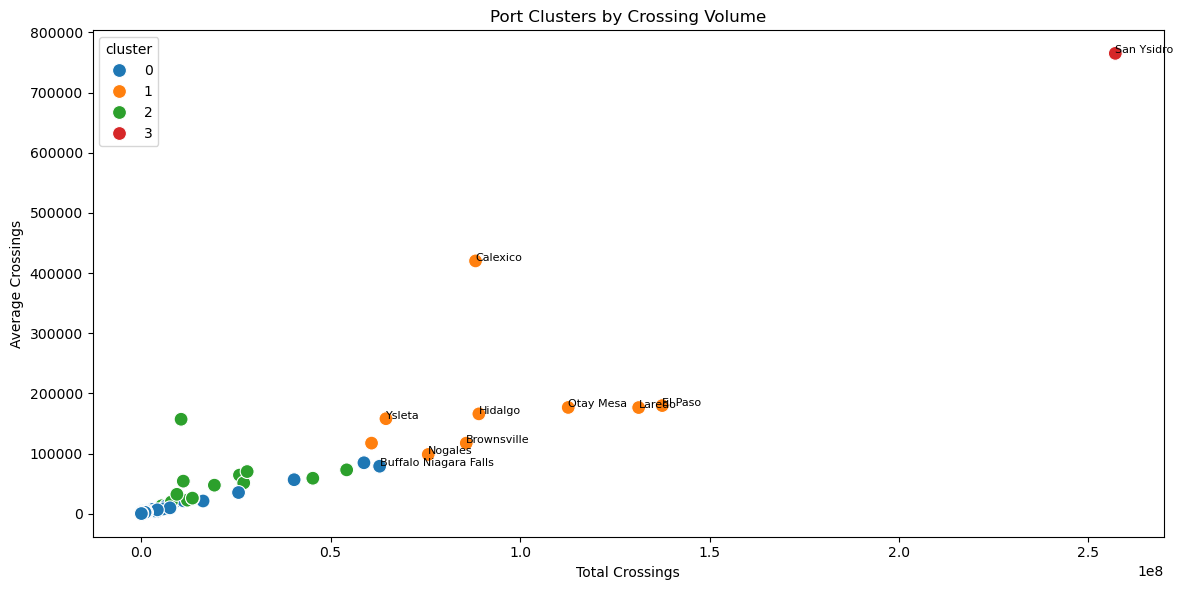

In [18]:
# ── Visualize Clusters ─────────────────────────────────────────
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=port_df,
    x="total_crossings",
    y="avg_crossings",
    hue="cluster",
    palette="tab10",
    s=100
)

# Label the top 10 busiest ports for context
for _, row in port_df.nlargest(10, "total_crossings").iterrows():
    plt.annotate(row["port_name"],
                (row["total_crossings"], row["avg_crossings"]),
                fontsize=8, ha="left")

plt.title("Port Clusters by Crossing Volume")
plt.xlabel("Total Crossings")
plt.ylabel("Average Crossings")
plt.tight_layout()
plt.show()

## Section 6 — Initial Findings and Conclusions

In [19]:
# ── Final Findings ─────────────────────────────────────────────
print("""
════════════════════════════════════════════════════════
          BORDER CROSSING DATA — KEY FINDINGS
════════════════════════════════════════════════════════

EDA FINDINGS:
─────────────
1. COVID-19 Impact
   Crossings dropped sharply in early 2020 and recovered
   gradually through 2021-2022, stabilizing at 28-33M monthly.

2. US-Mexico Dominance
   US-Mexico border sees 4x more crossings than US-Canada
   despite having fewer ports in the dataset.

3. Personal Travel Dominates
   Personal vehicle passengers account for the majority of
   all crossings. Commercial traffic is a small fraction.

4. Seasonality
   July/August peak due to summer vacation travel.
   February is the slowest month of the year.
   December spikes due to holiday family travel.

CLUSTERING FINDINGS:
────────────────────
5. Four Distinct Port Groups Identified:
   - Cluster 0: 83 small quiet ports (mostly US-Canada rural)
   - Cluster 2: 18 medium volume ports (mixed border)
   - Cluster 1: 9 large high volume US-Mexico ports
   - Cluster 3: San Ysidro alone — uniquely dominant

6. San Ysidro is in a Category of Its Own
   So far above all other ports the algorithm isolated it
   as its own cluster. The world's busiest land border crossing
   with ~255 million total crossings in this dataset.

7. Texas Dominates US-Mexico Crossings
   5 of the top 10 busiest ports are in Texas alone.
════════════════════════════════════════════════════════
""")


════════════════════════════════════════════════════════
          BORDER CROSSING DATA — KEY FINDINGS
════════════════════════════════════════════════════════

EDA FINDINGS:
─────────────
1. COVID-19 Impact
   Crossings dropped sharply in early 2020 and recovered
   gradually through 2021-2022, stabilizing at 28-33M monthly.

2. US-Mexico Dominance
   US-Mexico border sees 4x more crossings than US-Canada
   despite having fewer ports in the dataset.

3. Personal Travel Dominates
   Personal vehicle passengers account for the majority of
   all crossings. Commercial traffic is a small fraction.

4. Seasonality
   July/August peak due to summer vacation travel.
   February is the slowest month of the year.
   December spikes due to holiday family travel.

CLUSTERING FINDINGS:
────────────────────
5. Four Distinct Port Groups Identified:
   - Cluster 0: 83 small quiet ports (mostly US-Canada rural)
   - Cluster 2: 18 medium volume ports (mixed border)
   - Cluster 1: 9 large high volum

In [20]:
# ── Save All Results ───────────────────────────────────────────
os.makedirs("data/cleaned", exist_ok=True)

# Save cleaned dataframe
df.to_csv("data/cleaned/cleaned_border_crossing.csv", index=False)

# Save clustering results
port_df.to_csv("data/cleaned/port_clusters.csv", index=False)

print("All results saved successfully!")
print(f"Cleaned data: {df.shape[0]} rows")
print(f"Port clusters: {port_df.shape[0]} ports across 4 clusters")

All results saved successfully!
Cleaned data: 49993 rows
Port clusters: 111 ports across 4 clusters
